import os
os.getcwd()


In [3]:
import os

os.listdir("data/raw")

['network.inp']

In [6]:
import wntr

print("wntr OK")

wntr OK


In [7]:
inp_file = "data/raw/network.inp"

wn = wntr.network.WaterNetworkModel(inp_file)

print("network loaded")

network loaded


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/wntr/epanet/io.py:2082: UserWarning: Not all curves were used in "data/raw/network.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


In [8]:
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()

print("simulation done")

simulation done


In [9]:
pressure = results.node["pressure"]

pressure.head()

name,J511,J411,J414,J415,J416,J417,J418,J419,J310,J311,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,29.965738,65.432152,34.590523,84.594238,99.197334,29.788765,28.907303,25.283440,53.824219,49.730915,...,68.696159,68.696159,-0.000001,2.999995,3.000001,2.500003,5.199999,1.000002,0.500002,2.500002
900,30.029882,65.407509,34.608917,84.652893,99.258301,29.821632,28.947327,25.330446,53.946548,49.853245,...,68.783211,68.783211,-0.000001,3.128434,2.954544,2.625167,5.265800,1.140496,0.557333,2.564230
1800,30.093964,65.382759,34.626823,84.711327,99.319115,29.853878,28.986664,25.376625,54.060474,49.967171,...,68.868301,68.868301,-0.000001,3.256668,2.909844,2.748490,5.331665,1.280589,0.613544,2.628394
2700,30.157978,65.358391,34.644424,84.769516,99.379753,29.885597,29.025360,25.422005,54.173622,50.080318,...,68.953011,68.953011,-0.000001,3.384725,2.865847,2.870920,5.397698,1.420265,0.668624,2.692492
3600,30.378782,65.563416,34.828739,86.612198,101.487633,30.043959,29.167658,25.535761,54.738674,50.641178,...,69.879311,69.879311,-0.000001,3.512559,2.822608,2.992391,5.463908,1.559484,0.722505,2.756516


In [10]:
import os

os.makedirs("data/processed", exist_ok=True)

pressure = pressure.reset_index()
pressure.rename(columns={"index": "time"}, inplace=True)

pressure.to_csv("data/processed/pressure.csv", index=False)

print("pressure.csv saved")

pressure.csv saved


In [11]:
import pandas as pd

df = pd.read_csv("data/processed/pressure.csv")

df.head()

,time,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,29.965738,65.432150,34.590523,84.594240,99.197334,29.788765,28.907303,25.283440,53.824220,...,68.69616,68.69616,-0.000001,2.999995,3.000001,2.500003,5.199999,1.000002,0.500002,2.500002
1,900,30.029882,65.407510,34.608917,84.652890,99.258300,29.821632,28.947327,25.330446,53.946550,...,68.78321,68.78321,-0.000001,3.128434,2.954544,2.625167,5.265799,1.140496,0.557333,2.564230
2,1800,30.093964,65.382760,34.626823,84.711330,99.319115,29.853878,28.986664,25.376625,54.060474,...,68.86830,68.86830,-0.000001,3.256668,2.909844,2.748490,5.331665,1.280590,0.613544,2.628394
3,2700,30.157978,65.358390,34.644424,84.769516,99.379750,29.885597,29.025360,25.422005,54.173622,...,68.95301,68.95301,-0.000001,3.384725,2.865847,2.870920,5.397698,1.420265,0.668624,2.692492
4,3600,30.378782,65.563416,34.828740,86.612200,101.487630,30.043959,29.167658,25.535760,54.738674,...,69.87931,69.87931,-0.000001,3.512559,2.822608,2.992391,5.463908,1.559484,0.722505,2.756516


In [12]:
sim = wntr.sim.EpanetSimulator(wn)
results = sim.run_sim()

print("simulation done")

simulation done


In [13]:
df = pd.read_csv("data/processed/pressure.csv")

df.shape

(673, 397)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 673 entries, 0 to 672
Columns: 397 entries, time to T4
dtypes: float64(396), int64(1)
memory usage: 2.0 MB


In [15]:
df.describe()

,time,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
count,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,...,673.000000,673.000000,6.730000e+02,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000
mean,302400.000000,31.003670,66.189010,38.333224,82.879075,98.574085,34.525339,30.750366,27.507240,53.980845,...,67.999941,67.999941,-1.293945e-06,4.184845,2.722872,3.427682,5.387233,2.739128,3.150213,3.622881
std,174980.384615,0.591742,2.341421,3.535097,7.066710,4.430942,3.986860,2.717538,2.195197,1.806490,...,5.025332,5.025332,2.119157e-22,0.659439,1.126007,0.731915,0.162687,0.727010,1.392890,0.531126
min,0.000000,29.203785,61.230545,33.645508,60.178100,82.578100,29.412410,23.730488,21.742140,47.167797,...,54.009210,54.009210,-1.293945e-06,2.999995,0.584479,2.039864,4.905458,1.000002,0.500002,2.307092
25%,151200.000000,30.560019,64.389190,35.697063,83.823494,98.349470,31.727238,29.747070,26.310160,53.116440,...,67.096160,67.096160,-1.293945e-06,3.626097,1.736734,2.750815,5.291928,2.115636,1.974010,3.202619
50%,302400.000000,30.992514,65.968880,36.868168,85.146484,99.637850,32.818450,31.221724,27.917465,53.989320,...,69.027740,69.027740,-1.293945e-06,4.219707,2.903747,3.339812,5.499999,2.753439,3.402095,3.603246
75%,453600.000000,31.509290,67.630990,41.708168,86.451450,100.889890,38.687263,32.312016,28.821700,55.216675,...,71.310680,71.310680,-1.293945e-06,4.752753,3.648348,4.086027,5.499999,3.357681,4.249401,4.104183
max,604800.000000,32.315773,72.626724,47.211525,90.371056,105.474780,44.191254,36.195965,32.089760,58.575325,...,78.142000,78.142000,-1.293945e-06,5.292144,4.508677,4.790216,5.499999,3.999214,5.499953,4.493033


In [16]:
df.isnull().sum().sum()

np.int64(0)

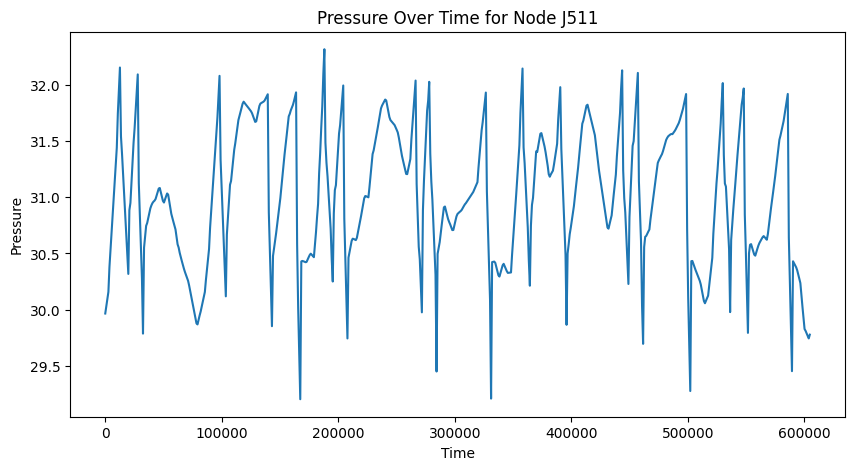

In [17]:
import matplotlib.pyplot as plt

pressure_cols = df.columns.drop("time")

plt.figure(figsize=(10, 5))
plt.plot(df["time"], df[pressure_cols[0]])
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.title(f"Pressure Over Time for Node {pressure_cols[0]}")
plt.show()

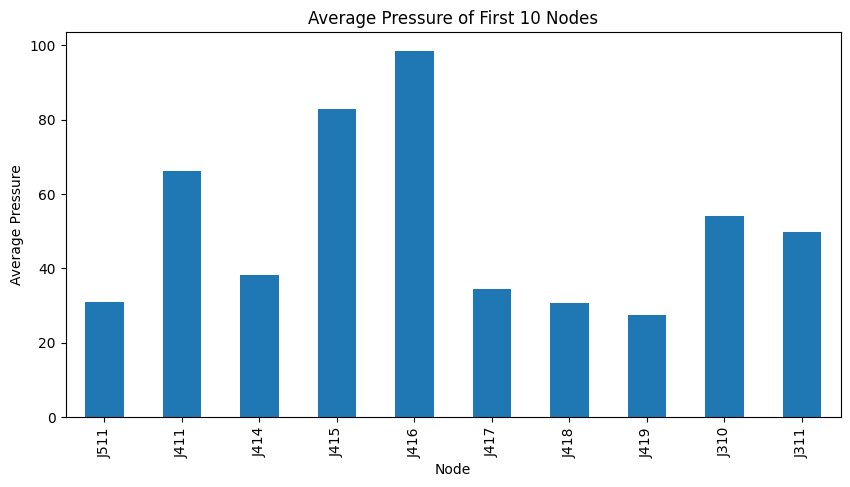

In [18]:
plt.figure(figsize=(10, 5))
df[pressure_cols[:10]].mean().plot(kind="bar")
plt.xlabel("Node")
plt.ylabel("Average Pressure")
plt.title("Average Pressure of First 10 Nodes")
plt.show()

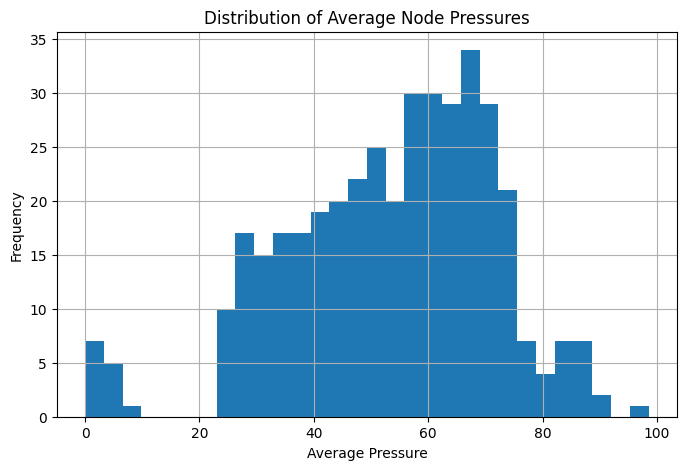

In [19]:
plt.figure(figsize=(8, 5))
df[pressure_cols].mean().hist(bins=30)
plt.xlabel("Average Pressure")
plt.ylabel("Frequency")
plt.title("Distribution of Average Node Pressures")
plt.show()

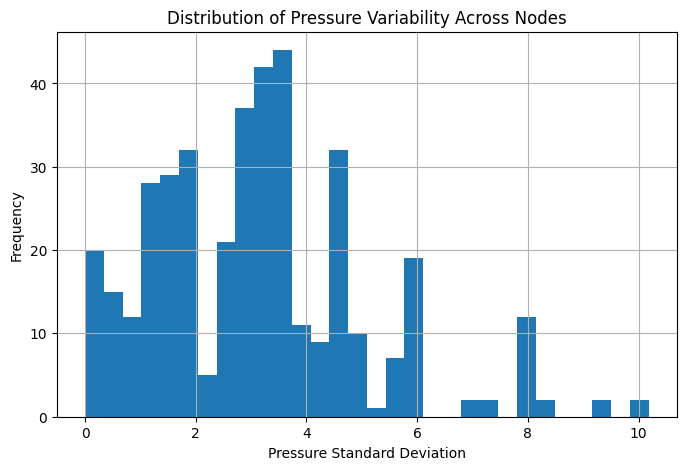

In [20]:
plt.figure(figsize=(8, 5))
df[pressure_cols].std().hist(bins=30)
plt.xlabel("Pressure Standard Deviation")
plt.ylabel("Frequency")
plt.title("Distribution of Pressure Variability Across Nodes")
plt.show()

In [21]:
from scipy.stats import ttest_ind

df["mean_pressure"] = df[pressure_cols].mean(axis=1)

early = df[df["time"] <= df["time"].median()]["mean_pressure"]
late = df[df["time"] > df["time"].median()]["mean_pressure"]

t_stat, p_value = ttest_ind(early, late, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.734809928648965
p-value: 0.46271280907612106


### Hypothesis Test Result

For the hypothesis test, I compared the average pressure values in the early time period and the late time period.

- H0: There is no significant difference between the average pressure values of the early and late time periods.
- H1: There is a significant difference between the average pressure values of the early and late time periods.

The p-value is approximately 0.426. Since this value is greater than 0.05, I fail to reject the null hypothesis.

This means that, based on this simulation data, there is no statistically significant difference between the average pressure values in the early and late time periods.


In [26]:
df = pd.read_csv("data/processed/pressure.csv")

pressure_cols = df.columns.drop("time")

features = pd.DataFrame()

features["time"] = df["time"]
features["mean_pressure"] = df[pressure_cols].mean(axis=1)
features["min_pressure"] = df[pressure_cols].min(axis=1)
features["max_pressure"] = df[pressure_cols].max(axis=1)
features["std_pressure"] = df[pressure_cols].std(axis=1)

features["pressure_range"] = features["max_pressure"] - features["min_pressure"]

features.head()


,time,mean_pressure,min_pressure,max_pressure,std_pressure,pressure_range
0,0,54.022241,-0.000001,99.197334,19.510167,99.197335
1,900,54.067969,-0.000001,99.258300,19.510989,99.258301
2,1800,54.112559,-0.000001,99.319115,19.512169,99.319116
3,2700,54.157059,-0.000001,99.379750,19.513550,99.379751
4,3600,55.016660,-0.000001,101.487630,19.808536,101.487631


In [27]:
threshold = features["min_pressure"].quantile(0.10)

features["anomaly"] = (features["min_pressure"] < threshold).astype(int)

features["anomaly"].value_counts()

anomaly
0    673
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = features.drop(columns=["time", "anomaly"])
y = features["anomaly"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

ModuleNotFoundError: No module named 'sklearn'

In [29]:
import sys
!{sys.executable} -m pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/49/d8/9be608c6024d021041c7f0b3928d4749a706f4e2c3832bbede4fb4f58c95/scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 9.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 13.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = features.drop(columns=["time", "anomaly"])
y = features["anomaly"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       135

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [31]:
threshold = features["min_pressure"].quantile(0.10)

features["anomaly"] = (features["min_pressure"] <= threshold).astype(int)

features["anomaly"].value_counts()

anomaly
1    673
Name: count, dtype: int64

In [32]:
threshold = features["mean_pressure"].quantile(0.10)

features["anomaly"] = (features["mean_pressure"] <= threshold).astype(int)

features["anomaly"].value_counts()

anomaly
0    605
1     68
Name: count, dtype: int64

In [34]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[135]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       135

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = features.drop(columns=["time", "anomaly"])
y = features["anomaly"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[121   0]
 [  0  14]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       121
           1       1.00      1.00      1.00        14

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg       1.00      1.00      1.00       135



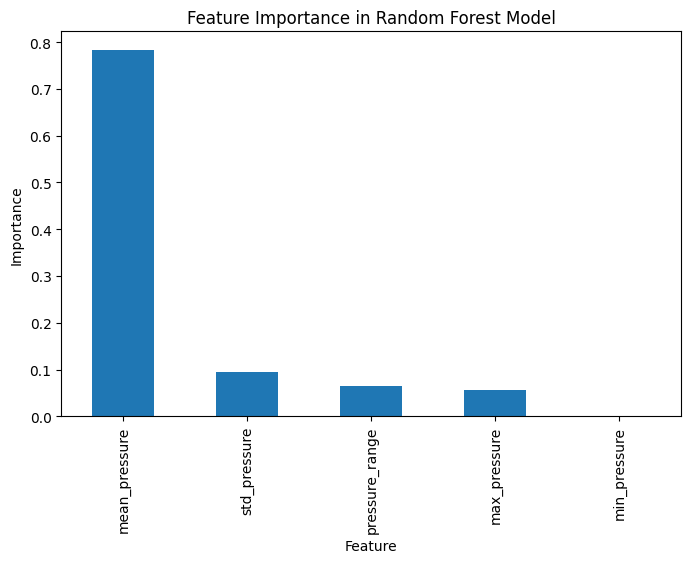

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind="bar")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()

In [38]:
features.to_csv("data/processed/features_with_anomaly_labels.csv", index=False)

print("features_with_anomaly_labels.csv saved")

features_with_anomaly_labels.csv saved


## Feature Importance Analysis

The feature importance results show that "mean_pressure" is the most influential variable in detecting anomalies.

This is expected, since anomaly labels were created based on pressure levels. Other features such as standard deviation, pressure range, and maximum pressure also contribute to the model, but to a lesser extent.

This result indicates that pressure-based features are effective indicators for anomaly detection in water distribution networks.

In [ ]:
## Final Machine Learning Analysis

In this section, I apply machine learning methods to detect low-pressure anomaly patterns in the water distribution network data. 
Since the dataset does not contain real manually verified anomaly labels, anomaly labels are created using a statistical threshold
based on unusually low minimum pressure values. This approach is used as a practical data-driven approximation for the course project.
    

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pressure_df = pd.read_csv("data/processed/pressure.csv")

print("Pressure dataset shape:", pressure_df.shape)
display(pressure_df.head())

pressure_numeric = pressure_df.select_dtypes(include=[np.number])

print("Numeric pressure dataset shape:", pressure_numeric.shape)

features = pd.DataFrame()

features["mean_pressure"] = pressure_numeric.mean(axis=1)
features["min_pressure"] = pressure_numeric.min(axis=1)
features["max_pressure"] = pressure_numeric.max(axis=1)
features["std_pressure"] = pressure_numeric.std(axis=1)
features["pressure_range"] = features["max_pressure"] - features["min_pressure"]

features = features.dropna().copy()

print("Feature dataset shape:", features.shape)
display(features.head())

features["anomaly"] = 0

n_anomalies = max(1, int(0.10 * len(features)))

anomaly_indices = features.sort_values("min_pressure").head(n_anomalies).index

features.loc[anomaly_indices, "anomaly"] = 1

print("Number of anomaly samples:", n_anomalies)
print("Class distribution:")
print(features["anomaly"].value_counts())

X = features[["mean_pressure", "max_pressure", "std_pressure", "pressure_range"]]
y = features["anomaly"]

print("Input feature dataset:")
display(X.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set class distribution:")
print(y_train.value_counts())

print("Test set class distribution:")
print(y_test.value_counts())


log_reg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

log_reg_predictions = log_reg_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_reg_predictions))
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_reg_predictions))
print("Classification Report:")
print(classification_report(y_test, log_reg_predictions, zero_division=0))

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print("Classification Report:")
print(classification_report(y_test, rf_predictions, zero_division=0))

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Random Forest Feature Importance:")
display(feature_importance)

iso_model = IsolationForest(
    contamination=0.10,
    random_state=42
)

iso_model.fit(X_train)

iso_predictions_raw = iso_model.predict(X_test)

iso_predictions = np.where(iso_predictions_raw == -1, 1, 0)

print("Isolation Forest Results")
print("Accuracy:", accuracy_score(y_test, iso_predictions))
print("Confusion Matrix:")
print(confusion_matrix(y_test, iso_predictions))
print("Classification Report:")
print(classification_report(y_test, iso_predictions, zero_division=0))

results_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Isolation Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_reg_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, iso_predictions)
    ]
})

display(results_summary)

Pressure dataset shape: (673, 397)


,time,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,29.965738,65.432150,34.590523,84.594240,99.197334,29.788765,28.907303,25.283440,53.824220,...,68.69616,68.69616,-0.000001,2.999995,3.000001,2.500003,5.199999,1.000002,0.500002,2.500002
1,900,30.029882,65.407510,34.608917,84.652890,99.258300,29.821632,28.947327,25.330446,53.946550,...,68.78321,68.78321,-0.000001,3.128434,2.954544,2.625167,5.265799,1.140496,0.557333,2.564230
2,1800,30.093964,65.382760,34.626823,84.711330,99.319115,29.853878,28.986664,25.376625,54.060474,...,68.86830,68.86830,-0.000001,3.256668,2.909844,2.748490,5.331665,1.280590,0.613544,2.628394
3,2700,30.157978,65.358390,34.644424,84.769516,99.379750,29.885597,29.025360,25.422005,54.173622,...,68.95301,68.95301,-0.000001,3.384725,2.865847,2.870920,5.397698,1.420265,0.668624,2.692492
4,3600,30.378782,65.563416,34.828740,86.612200,101.487630,30.043959,29.167658,25.535760,54.738674,...,69.87931,69.87931,-0.000001,3.512559,2.822608,2.992391,5.463908,1.559484,0.722505,2.756516


Numeric pressure dataset shape: (673, 397)
Feature dataset shape: (673, 5)


,mean_pressure,min_pressure,max_pressure,std_pressure,pressure_range
0,53.886165,-0.000001,99.197334,19.673244,99.197335
1,56.198780,-0.000001,900.000000,46.714439,900.000001
2,58.510260,-0.000001,1800.000000,89.764441,1800.000001
3,60.821651,-0.000001,2700.000000,134.213562,2700.000001
4,63.946089,-0.000001,3600.000000,179.014146,3600.000001


Number of anomaly samples: 67
Class distribution:
anomaly
0    606
1     67
Name: count, dtype: int64
Input feature dataset:


,mean_pressure,max_pressure,std_pressure,pressure_range
0,53.886165,99.197334,19.673244,99.197335
1,56.198780,900.000000,46.714439,900.000001
2,58.510260,1800.000000,89.764441,1800.000001
3,60.821651,2700.000000,134.213562,2700.000001
4,63.946089,3600.000000,179.014146,3600.000001


Training set class distribution:
anomaly
0    484
1     54
Name: count, dtype: int64
Test set class distribution:
anomaly
0    122
1     13
Name: count, dtype: int64
Logistic Regression Results
Accuracy: 0.9037037037037037
Confusion Matrix:
[[122   0]
 [ 13   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95       122
           1       0.00      0.00      0.00        13

    accuracy                           0.90       135
   macro avg       0.45      0.50      0.47       135
weighted avg       0.82      0.90      0.86       135

Random Forest Results
Accuracy: 1.0
Confusion Matrix:
[[122   0]
 [  0  13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       122
           1       1.00      1.00      1.00        13

    accuracy                           1.00       135
   macro avg       1.00      1.00      1.00       135
weighted avg  

,feature,importance
2,std_pressure,0.266523
1,max_pressure,0.256698
0,mean_pressure,0.243833
3,pressure_range,0.232947


Isolation Forest Results
Accuracy: 0.8074074074074075
Confusion Matrix:
[[109  13]
 [ 13   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       122
           1       0.00      0.00      0.00        13

    accuracy                           0.81       135
   macro avg       0.45      0.45      0.45       135
weighted avg       0.81      0.81      0.81       135



,Model,Accuracy
0,Logistic Regression,0.903704
1,Random Forest,1.000000
2,Isolation Forest,0.807407
